In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv("ford.csv")

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [5]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [6]:
df.duplicated().sum()

np.int64(154)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [10]:
df["model"]=df.model.str.strip()

In [11]:
df.year.unique()

array([2017, 2018, 2019, 2015, 2014, 2016, 2013, 2020, 2012, 2008, 2010,
       2009, 2011, 1998, 2007, 2005, 2006, 2002, 2003, 1996, 2004, 2000,
       2060])

Here we can see year 2060.which is unrealistic.so lets see 2060 deeply in this data set

In [12]:
df[df.year==2060]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17726,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4


Yeah ,only one row has year 2060.so we can drop this .

In [13]:
df.drop(index=17726,inplace=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020')])

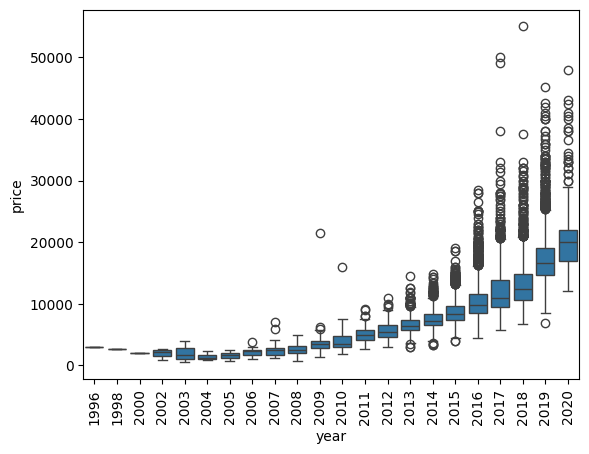

In [14]:
sns.boxplot(df,x="year",y="price")
plt.xticks(rotation=90)

<Axes: xlabel='Count', ylabel='model'>

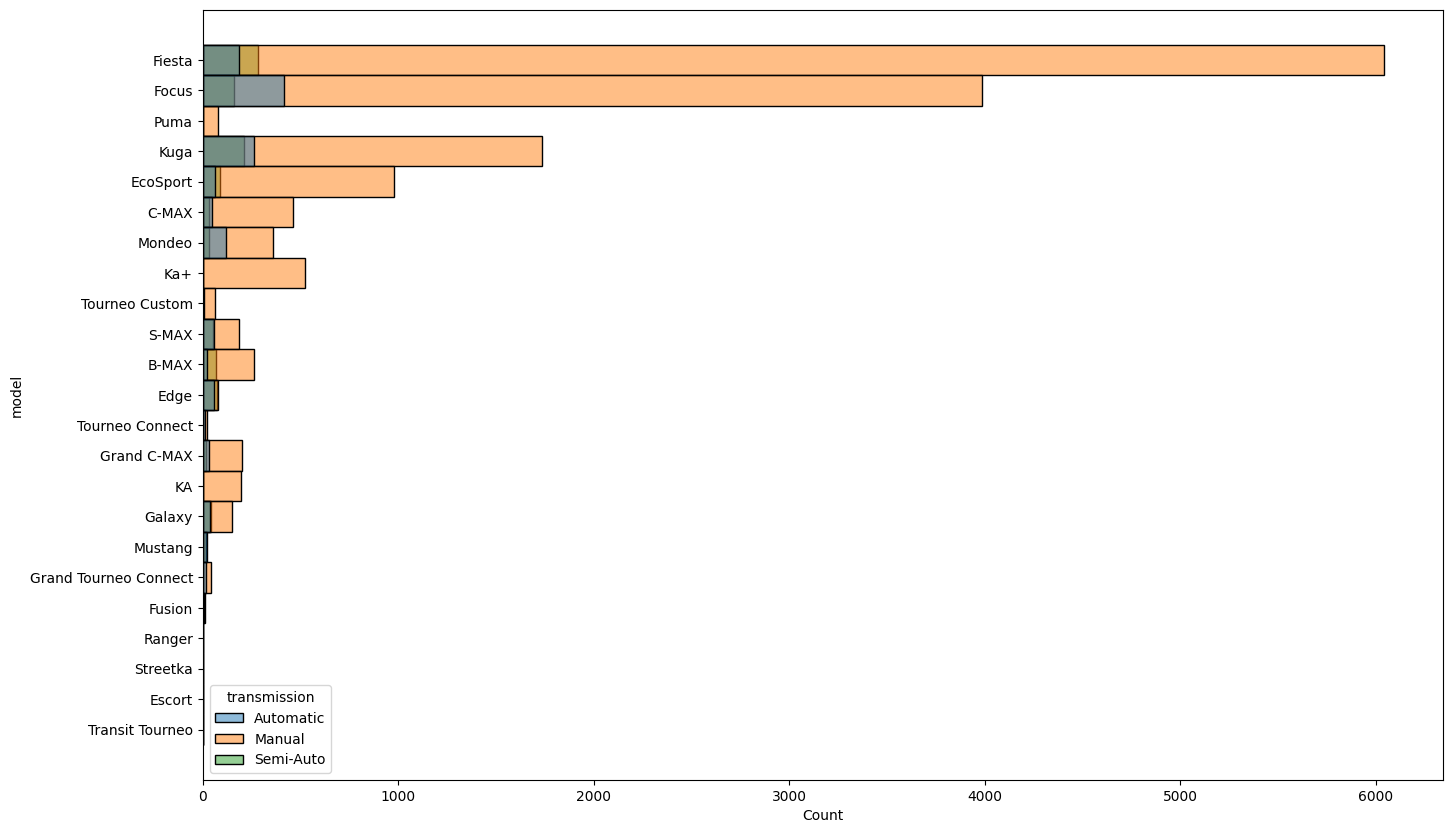

In [15]:
plt.figure(figsize=(16,10))
sns.histplot(df,y="model",hue="transmission")

Fiesta ,Focus and Kuga are top three respectively.All the brand has manual car mostly

In [16]:
df.head()
"transmission","model","year","fuelType","engineSize"

('transmission', 'model', 'year', 'fuelType', 'engineSize')

In [17]:
df.groupby(["year","model","transmission"]).size().reset_index().rename(columns={0:"count"})

,year,model,transmission,count
0,1996,Escort,Manual,1
1,1998,Fiesta,Manual,1
2,2000,Fiesta,Manual,1
3,2002,Mondeo,Manual,1
4,2002,Puma,Manual,2
...,...,...,...,...
371,2020,Puma,Manual,45
372,2020,S-MAX,Automatic,2
373,2020,S-MAX,Manual,1
374,2020,S-MAX,Semi-Auto,2


<Figure size 1200x2000 with 0 Axes>

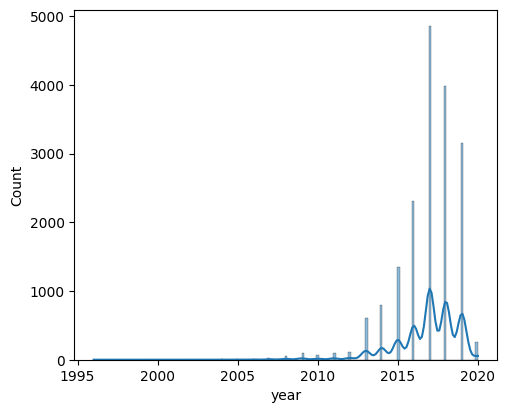

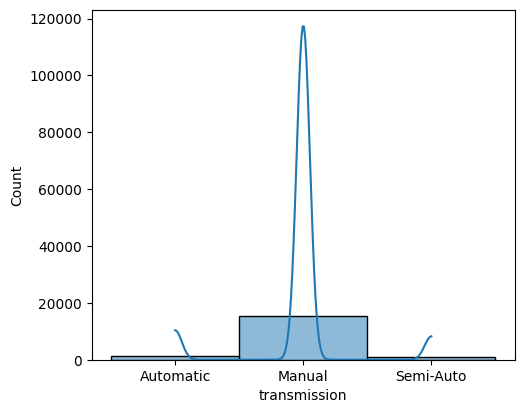

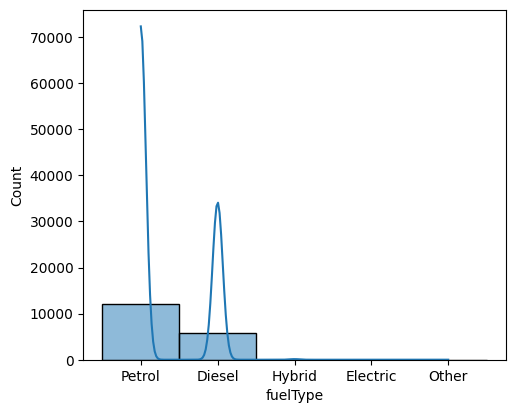

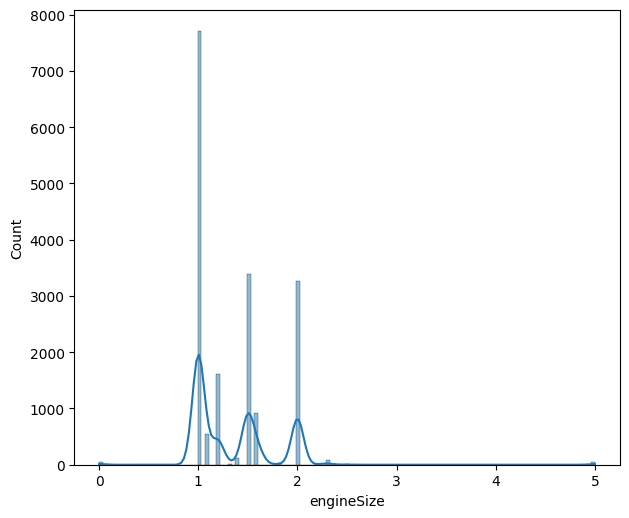

<Figure size 1200x2000 with 0 Axes>

In [18]:
def histogram(x,y): 
    plt.figure(figsize=(12,10))
    plt.subplot(2,2,y)
    sns.histplot(df,x=x,kde=True)
histogram("year",1)
histogram("transmission",2)
histogram('fuelType',3)
histogram("engineSize",4)
plt.tight_layout()
plt.figure(figsize=(12,20))

In [19]:
df.fuelType.value_counts()

fuelType
Petrol      12080
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

Here 1 FuelType is other.that does not make any sense.so i will drop this other category

In [20]:
df.drop(index=df[df.fuelType=="Other"].index,inplace=True)

In [21]:
mod_mil=df.groupby("model").mileage.mean().reset_index().sort_values(by="mileage",ascending=False).reset_index(drop="index")

This is the data frame of each model with avg mileage (in descending order).Top 10 are is shown below

([<matplotlib.patches.Wedge at 0x1ab4a9ffb60>,
 [Text(0.9190793424338679, 0.6043948728367318, 'Ranger'),
  Text(-0.05014469354702615, 1.098856455461347, 'Streetka'),
  Text(-0.8844923138896218, 0.6539673896076033, 'Fusion'),
  Text(-1.0908041075907917, -0.1419380106351245, 'Escort'),
  Text(-0.7961280896567626, -0.7590652573128834, 'Mondeo'),
  Text(-0.296874865226243, -1.0591814360141043, 'KA'),
  Text(0.1959177239562438, -1.0824122345205662, 'Galaxy'),
  Text(0.6292253706657132, -0.9022612886024737, 'S-MAX'),
  Text(0.9309246706835388, -0.5859857144271907, 'C-MAX'),
  Text(1.0808593666412372, -0.20431110969280128, 'B-MAX')],
 [Text(0.5013160049639279, 0.32966993063821726, '18.52%'),
  Text(-0.027351651025650625, 0.5993762484334619, '14.42%'),
  Text(-0.4824503530307027, 0.3567094852405108, '13.86%'),
  Text(-0.5949840586858863, -0.07742073307370427, '10.52%'),
  Text(-0.434251685267325, -0.41403559489793634, '9.60%'),
  Text(-0.1619317446688598, -0.5777353287349659, '7.46%'),
  Text(

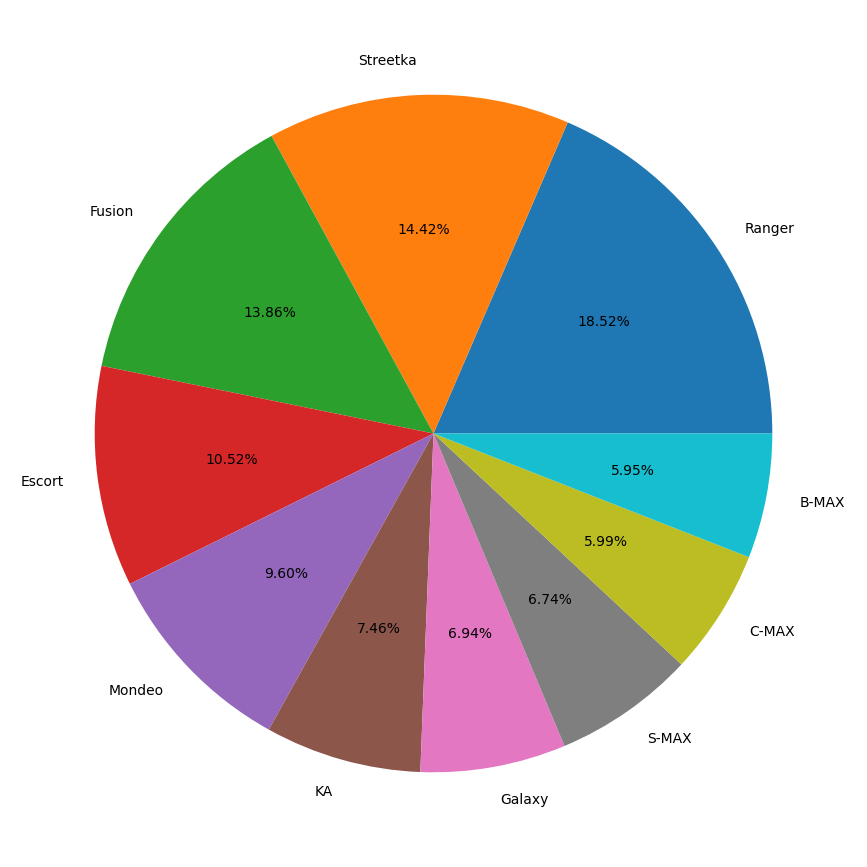

In [22]:
plt.figure(figsize=(12,11))
plt.pie(mod_mil[:10]["mileage"],labels=mod_mil[:10]['model'],autopct="%1.2f%%")

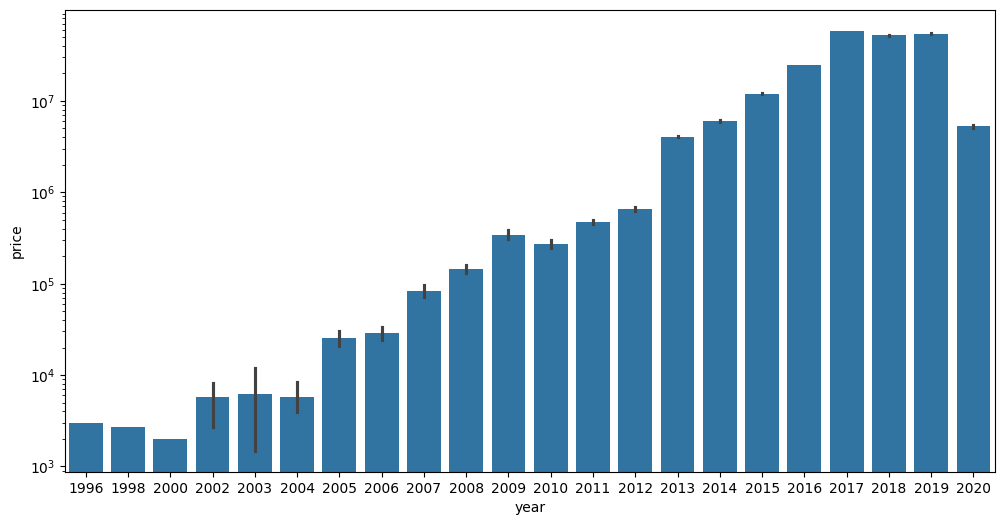

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(data=df,x="year",y="price",estimator="sum")
plt.yscale("log")

most amount of sell in 2017 and less in 2000

In [24]:
df.engineSize.unique()

array([1. , 1.5, 1.6, 1.2, 2. , 1.1, 2.3, 1.4, 5. , 2.2, 2.5, 1.8, 1.3,
       3.2, 0. , 1.7])

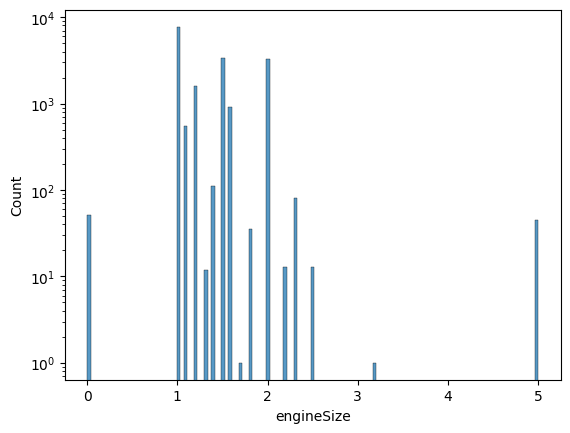

In [25]:
sns.histplot(df["engineSize"],kde=False)
plt.yscale("log")

In [26]:
df.engineSize.value_counts()

engineSize
1.0    7702
1.5    3393
2.0    3272
1.2    1613
1.6     918
1.1     550
1.4     111
2.3      80
0.0      51
5.0      45
1.8      35
2.2      13
2.5      13
1.3      12
3.2       1
1.7       1
Name: count, dtype: int64

here we can see that 51 of data has 0L engine size .which is unrealistic.so i will drop those row of 0L engine size

In [27]:
df.drop(index=df[df["engineSize"]==0].index,inplace=True)

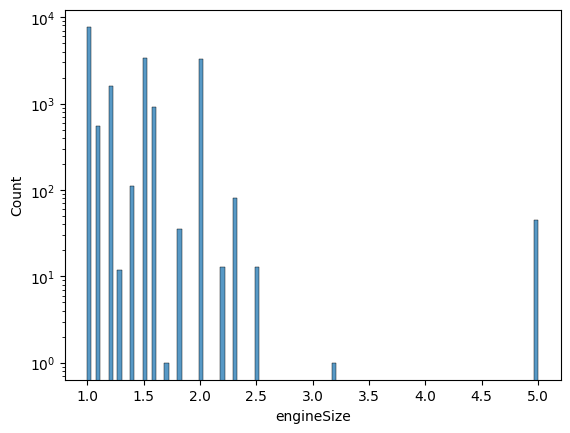

In [28]:
sns.histplot(df["engineSize"],kde=False)
plt.yscale("log")

# Now perfect.
Most of the car use 1L to 2.5L engine

In [29]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [30]:
df["model"].unique()

array(['Fiesta', 'Focus', 'Puma', 'Kuga', 'EcoSport', 'C-MAX', 'Mondeo',
       'Ka+', 'Tourneo Custom', 'S-MAX', 'B-MAX', 'Edge',
       'Tourneo Connect', 'Grand C-MAX', 'KA', 'Galaxy', 'Mustang',
       'Grand Tourneo Connect', 'Fusion', 'Ranger', 'Streetka', 'Escort',
       'Transit Tourneo'], dtype=object)

In [31]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17759.000000,17759.000000,17759.000000,17759.000000,17759.000000,17759.000000
mean,2016.858776,12271.210485,23390.482234,113.328847,57.911915,1.354463
std,2.027597,4738.714536,19422.934068,62.032655,10.134091,0.427091
min,1996.000000,495.000000,1.000000,0.000000,20.800000,1.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11290.000000,18291.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31107.000000,145.000000,65.700000,1.500000
max,2020.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [32]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [33]:
df_train=pd.get_dummies(data=df,columns=["model","year","transmission","fuelType","engineSize"],dtype=int,drop_first=True)

In [34]:
df_train

,price,mileage,tax,mpg,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,model_Focus,...,engineSize_1.5,engineSize_1.6,engineSize_1.7,engineSize_1.8,engineSize_2.0,engineSize_2.2,engineSize_2.3,engineSize_2.5,engineSize_3.2,engineSize_5.0
0,12000,15944,150,57.7,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,14000,9083,150,57.7,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,13000,12456,150,57.7,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,17500,10460,145,40.3,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,16500,1482,145,48.7,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,8999,16700,150,47.1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17962,7499,40700,30,57.7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17963,9999,7010,20,67.3,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
17964,8299,5007,145,57.7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


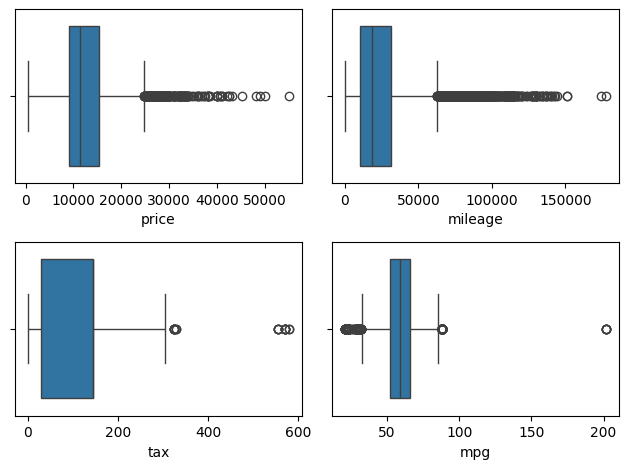

In [35]:
j=1
for i in ["price","mileage","tax","mpg"]: 
    plt.subplot(2,2,j)
    sns.boxplot(data=df,x=i)
    j+=1
plt.tight_layout()

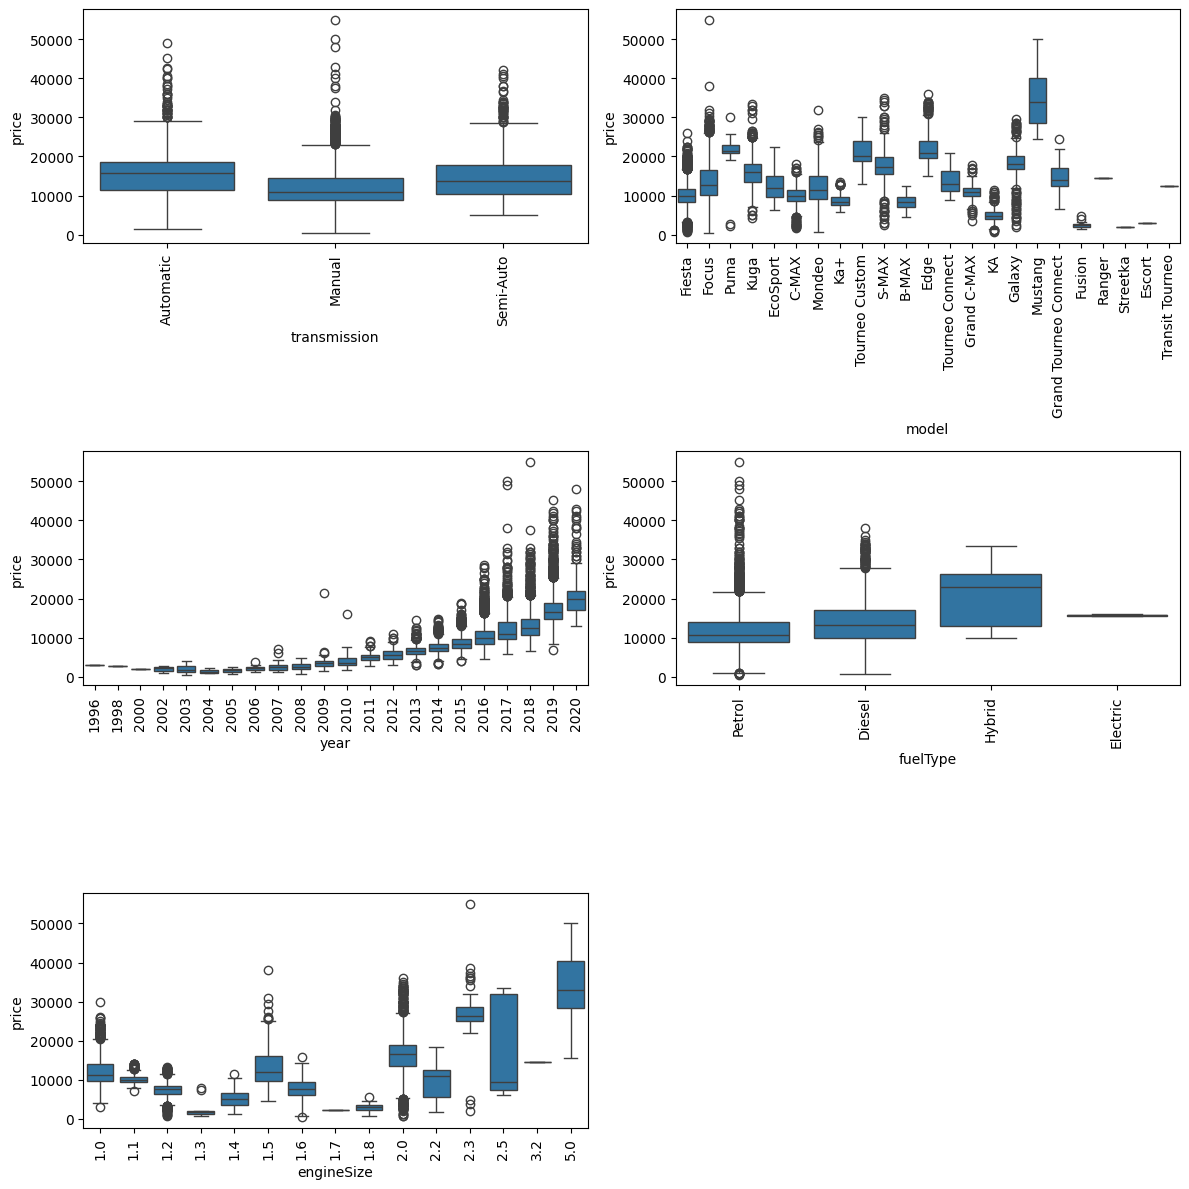

In [40]:
j=1
plt.figure(figsize=(12,12))
for i in ["transmission","model","year","fuelType","engineSize"]: 
    plt.subplot(3,2,j)
    sns.boxplot(data=df,x=i,y="price")
    j+=1
    plt.xticks(rotation=90)
plt.tight_layout()

# we can see this 4 numerical columns has outliers ..all are valid.now we use Standardization

In [41]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
df_train[["mileage","tax","mpg"]]=scale.fit_transform(df_train[["mileage","tax","mpg"]])

In [42]:
df_train.head()

,price,mileage,tax,mpg,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,model_Focus,...,engineSize_1.5,engineSize_1.6,engineSize_1.7,engineSize_1.8,engineSize_2.0,engineSize_2.2,engineSize_2.3,engineSize_2.5,engineSize_3.2,engineSize_5.0
0,12000,-0.383397,0.591175,-0.020912,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,14000,-0.736649,0.591175,-0.020912,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,13000,-0.562983,0.591175,-0.020912,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,17500,-0.665751,0.510571,-1.737937,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,16500,-1.128002,0.510571,-0.909028,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


# Feature selection

In [44]:
num_feature=["mileage","tax","mpg"] 

In [45]:
from scipy.stats import pearsonr
alpha=0.05
selected_feature=[]
for i in num_feature: 
    corr,p=pearsonr(df_train[i],df_train["price"])
    selected_feature.append(i if p<alpha else '')

In [46]:
selected_feature

['mileage', 'tax', 'mpg']

In [47]:
qual=[]
for i in df_train.columns: 
    if df_train[i].nunique()<10: 
        qual.append(i)
qual

['model_C-MAX',
 'model_EcoSport',
 'model_Edge',
 'model_Escort',
 'model_Fiesta',
 'model_Focus',
 'model_Fusion',
 'model_Galaxy',
 'model_Grand C-MAX',
 'model_Grand Tourneo Connect',
 'model_KA',
 'model_Ka+',
 'model_Kuga',
 'model_Mondeo',
 'model_Mustang',
 'model_Puma',
 'model_Ranger',
 'model_S-MAX',
 'model_Streetka',
 'model_Tourneo Connect',
 'model_Tourneo Custom',
 'model_Transit Tourneo',
 'year_1998',
 'year_2000',
 'year_2002',
 'year_2003',
 'year_2004',
 'year_2005',
 'year_2006',
 'year_2007',
 'year_2008',
 'year_2009',
 'year_2010',
 'year_2011',
 'year_2012',
 'year_2013',
 'year_2014',
 'year_2015',
 'year_2016',
 'year_2017',
 'year_2018',
 'year_2019',
 'year_2020',
 'transmission_Manual',
 'transmission_Semi-Auto',
 'fuelType_Electric',
 'fuelType_Hybrid',
 'fuelType_Petrol',
 'engineSize_1.1',
 'engineSize_1.2',
 'engineSize_1.3',
 'engineSize_1.4',
 'engineSize_1.5',
 'engineSize_1.6',
 'engineSize_1.7',
 'engineSize_1.8',
 'engineSize_2.0',
 'engineSize_

In [48]:
df_train["price_bin"]=pd.qcut(df_train["price"],q=4)

In [49]:
from scipy.stats import chi2_contingency
qual_sel_feature=[]
for i in qual: 
    contingency_table=pd.crosstab(df_train[i],df_train["price_bin"])
    chi2,p,dof,expected=chi2_contingency(contingency_table)
    if p<0.05: 
        qual_sel_feature.append(i)

In [50]:
len(qual_sel_feature)

50

In [51]:
df_final=df_train[selected_feature+qual_sel_feature+["price"]]

In [68]:
X=df_final.drop(columns=["price",'transmission_Semi-Auto'])
y=df_final["price"]

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

In [70]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [71]:
y_pred=model.predict(X_test)

In [72]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)

In [73]:
r2

0.8982865931723094

In [74]:
n=(X_test.shape[0])
p=len(X_test.columns)
adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2

0.8967749906701545